# Optimisation et interprétation du modèle

Objectifs :
- optimiser les hyperparamètres du modèle XGBoost par recherche exhaustive (GridSearch)
- analyser l'importance des features au niveau global (quelles variables comptent le plus)
- analyser l'importance des features au niveau local (pourquoi le modèle a prédit tel résultat pour tel employé)
- formuler des recommandations pour les RH de TechNova

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, GridSearchCV
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
    make_scorer
)
from sklearn.inspection import permutation_importance

from xgboost import XGBClassifier
import shap

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

## Chargement des données préparées

Les features `X` et la cible `y` ont été construites dans le notebook 02.

In [2]:
X = pd.read_csv("../data/processed/X_model.csv")
y = pd.read_csv("../data/processed/y_model.csv").squeeze("columns")

print("X :", X.shape)
print("y :", y.shape)

X : (1470, 38)
y : (1470,)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)

X_train : (1176, 38)
X_test  : (294, 38)


In [4]:
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos

threshold = 0.545

print(f"scale_pos_weight : {scale_pos_weight:.2f}")
print(f"Seuil retenu (notebook 04) : {threshold}")

scale_pos_weight : 5.19
Seuil retenu (notebook 04) : 0.545


## Modèle de référence (avant fine-tuning)

On ré-entraîne le modèle du notebook 04 avec les mêmes hyperparamètres pour avoir un point de comparaison.

In [5]:
model_base = XGBClassifier(
    n_estimators=100,
    max_depth=2,
    learning_rate=0.05,
    subsample=0.6,
    colsample_bytree=0.7,
    min_child_weight=20,
    reg_alpha=0.5,
    reg_lambda=3.0,
    gamma=0.3,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=42
)

model_base.fit(X_train, y_train)

test_proba_base = model_base.predict_proba(X_test)[:, 1]
y_test_pred_base = (test_proba_base >= threshold).astype(int)

print("Modèle de référence (avant fine-tuning) :")
print(classification_report(y_test, y_test_pred_base, zero_division=0))

Modèle de référence (avant fine-tuning) :
              precision    recall  f1-score   support

           0       0.92      0.85      0.88       247
           1       0.43      0.62      0.51        47

    accuracy                           0.81       294
   macro avg       0.68      0.73      0.70       294
weighted avg       0.84      0.81      0.82       294



## Fine-tuning par recherche d'hyperparamètres

On utilise `GridSearchCV` pour tester exhaustivement les combinaisons d'hyperparamètres.  
La recherche se fait par validation croisée stratifiée répétée (5 folds × 3 répétitions = 15 évaluations par combinaison).

Le scorer par défaut de `GridSearchCV` évalue les prédictions au seuil 0.5.  
Or on utilise un seuil optimisé de 0.545 (déterminé dans le notebook 04 via la courbe précision-rappel).  
On définit donc un scorer personnalisé qui prend directement le modèle, calcule les probabilités et applique le seuil avant d'évaluer le F1.

On fixe `max_depth` à 2 et `scale_pos_weight` à sa valeur du notebook 04, et on explore les autres paramètres.

In [6]:
def f1_at_threshold_scorer(estimator, X, y_true):
    proba = estimator.predict_proba(X)[:, 1]
    y_pred = (proba >= threshold).astype(int)
    return f1_score(y_true, y_pred, zero_division=0)

scorer = f1_at_threshold_scorer

In [7]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [2],
    "learning_rate": [0.03, 0.05, 0.08],
    "subsample": [0.6, 0.7, 0.8],
    "colsample_bytree": [0.6, 0.7, 0.8],
    "min_child_weight": [10, 15, 20],
    "reg_alpha": [0.3, 0.5, 1.0],
    "reg_lambda": [2.0, 3.0, 5.0],
}

total_combinations = 1
for values in param_grid.values():
    total_combinations *= len(values)
print(f"Nombre de combinaisons : {total_combinations}")
print(f"Nombre de fits (5 folds x 3 répétitions) : {total_combinations * 15}")

Nombre de combinaisons : 2187
Nombre de fits (5 folds x 3 répétitions) : 32805


In [8]:
search = GridSearchCV(
    XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        gamma=0.3,
        objective="binary:logistic",
        eval_metric="aucpr",
        random_state=42
    ),
    param_grid=param_grid,
    scoring=scorer,
    cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42),
    n_jobs=-1
)

search.fit(X_train, y_train)

print("Meilleurs hyperparamètres :")
for param, value in search.best_params_.items():
    print(f"  {param} : {value}")

print(f"\nMeilleur F1 en CV (au seuil {threshold}) : {search.best_score_:.3f}")

Meilleurs hyperparamètres :
  colsample_bytree : 0.8
  learning_rate : 0.03
  max_depth : 2
  min_child_weight : 10
  n_estimators : 300
  reg_alpha : 1.0
  reg_lambda : 3.0
  subsample : 0.6

Meilleur F1 en CV (au seuil 0.545) : 0.578


## Évaluation du modèle fine-tuné

In [9]:
model_tuned = search.best_estimator_

train_proba_tuned = model_tuned.predict_proba(X_train)[:, 1]
test_proba_tuned = model_tuned.predict_proba(X_test)[:, 1]

y_train_pred_tuned = (train_proba_tuned >= threshold).astype(int)
y_test_pred_tuned = (test_proba_tuned >= threshold).astype(int)

print(f"Seuil appliqué : {threshold}")

print("\n--- Train ---")
print(classification_report(y_train, y_train_pred_tuned, zero_division=0))

print("--- Test ---")
print(classification_report(y_test, y_test_pred_tuned, zero_division=0))

Seuil appliqué : 0.545

--- Train ---
              precision    recall  f1-score   support

           0       0.95      0.90      0.93       986
           1       0.61      0.77      0.68       190

    accuracy                           0.88      1176
   macro avg       0.78      0.84      0.80      1176
weighted avg       0.90      0.88      0.89      1176

--- Test ---
              precision    recall  f1-score   support

           0       0.93      0.85      0.89       247
           1       0.46      0.68      0.55        47

    accuracy                           0.82       294
   macro avg       0.70      0.76      0.72       294
weighted avg       0.86      0.82      0.83       294



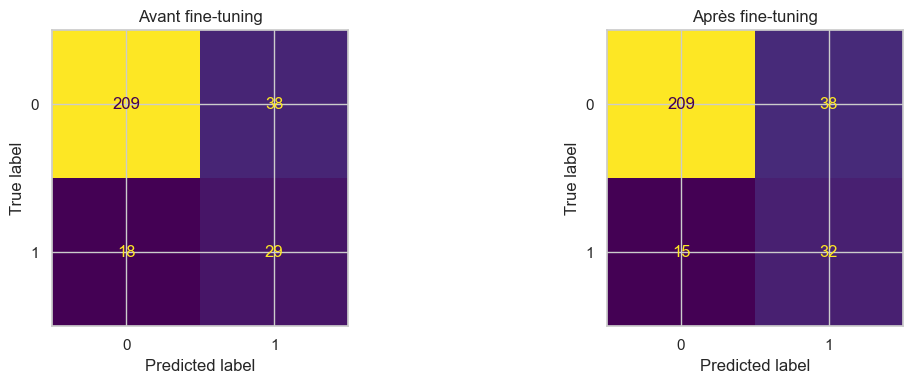

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_base, ax=axes[0], colorbar=False)
axes[0].set_title("Avant fine-tuning")

ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_tuned, ax=axes[1], colorbar=False)
axes[1].set_title("Après fine-tuning")

plt.tight_layout()
plt.show()

### Comparaison avant / après fine-tuning

In [11]:
comparison = pd.DataFrame({
    "modèle": ["Avant fine-tuning", "Après fine-tuning"],
    "test_precision": [
        precision_score(y_test, y_test_pred_base, zero_division=0),
        precision_score(y_test, y_test_pred_tuned, zero_division=0)
    ],
    "test_recall": [
        recall_score(y_test, y_test_pred_base, zero_division=0),
        recall_score(y_test, y_test_pred_tuned, zero_division=0)
    ],
    "test_f1": [
        f1_score(y_test, y_test_pred_base, zero_division=0),
        f1_score(y_test, y_test_pred_tuned, zero_division=0)
    ],
}).round(3)

display(comparison)

,modèle,test_precision,test_recall,test_f1
0,Avant fine-tuning,0.433,0.617,0.509
1,Après fine-tuning,0.457,0.681,0.547


On utilise le modèle fine-tuné pour la suite de l'analyse d'interprétabilité.

---

## Feature importance globale

L'importance globale permet de comprendre quelles variables pèsent le plus dans les décisions du modèle, tous employés confondus.  
On compare trois méthodes pour vérifier la cohérence des résultats.

### Méthode 1 : Feature importance native de XGBoost

XGBoost calcule pour chaque feature le nombre de fois où elle a été utilisée pour découper les arbres, pondéré par le gain obtenu.  
C'est rapide à calculer mais peut favoriser les variables numériques à beaucoup de valeurs distinctes.

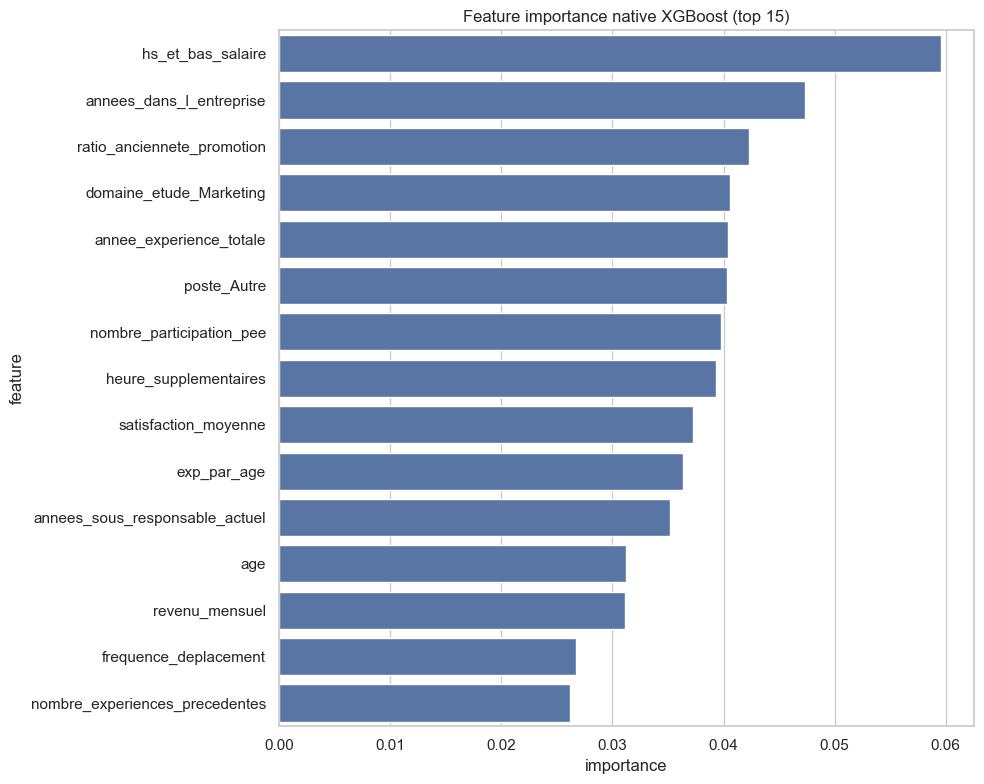

In [12]:
native_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model_tuned.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=native_importance.head(15), x="importance", y="feature")
plt.title("Feature importance native XGBoost (top 15)")
plt.tight_layout()
plt.show()

### Méthode 2 : Permutation Importance (sklearn)

Pour chaque feature, on mélange ses valeurs aléatoirement et on mesure la baisse de performance du modèle.  
Si le score baisse beaucoup, c'est que la feature était importante.  
Cette méthode est plus fiable que la native car elle mesure l'impact réel sur la prédiction.

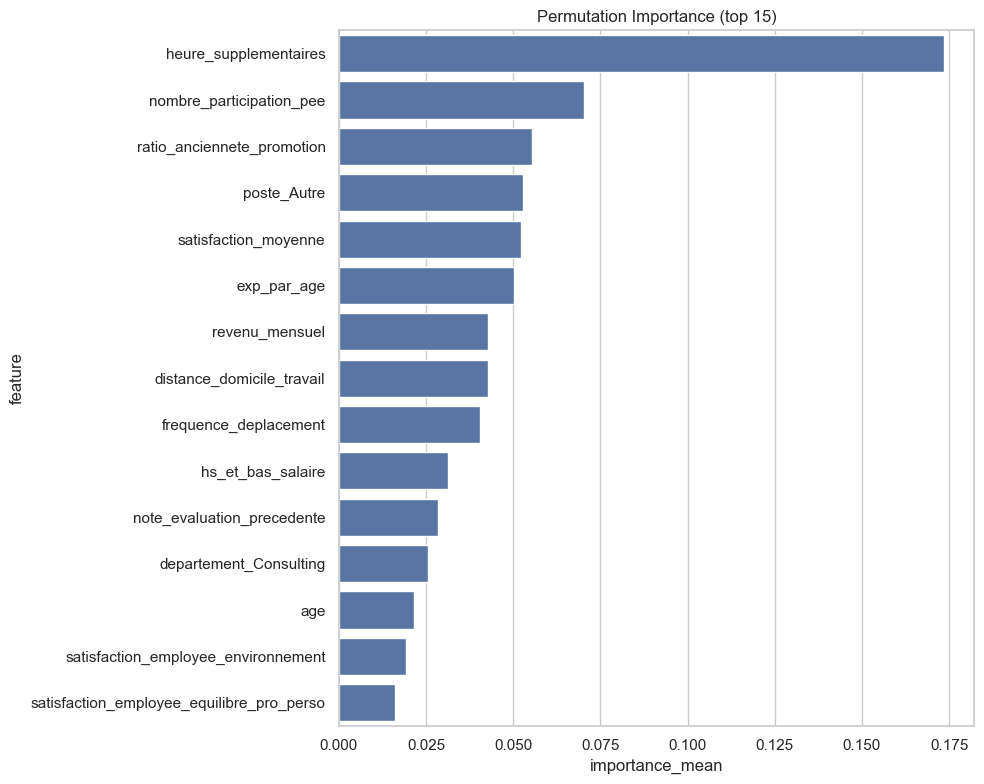

In [13]:
perm_result = permutation_importance(
    model_tuned, X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring=scorer
)

perm_importance = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}).sort_values("importance_mean", ascending=False)

plt.figure(figsize=(10, 8))
top_perm = perm_importance.head(15)
sns.barplot(data=top_perm, x="importance_mean", y="feature")
plt.title("Permutation Importance (top 15)")
plt.tight_layout()
plt.show()

### Méthode 3 : SHAP Beeswarm Plot

SHAP (SHapley Additive exPlanations) attribue à chaque feature, pour chaque observation, une valeur qui mesure sa contribution à la prédiction.  
Le beeswarm plot montre pour chaque feature :
- sa position verticale : son importance globale (les plus importantes sont en haut)
- chaque point = un employé
- la couleur : la valeur de la feature (rouge = élevée, bleu = faible)
- la position horizontale : l'impact sur la prédiction (droite = pousse vers le départ, gauche = pousse vers le maintien)

On utilise `TreeExplainer`, optimisé pour les modèles à base d'arbres.

In [14]:
explainer = shap.TreeExplainer(model_tuned)
shap_values = explainer(X_test)

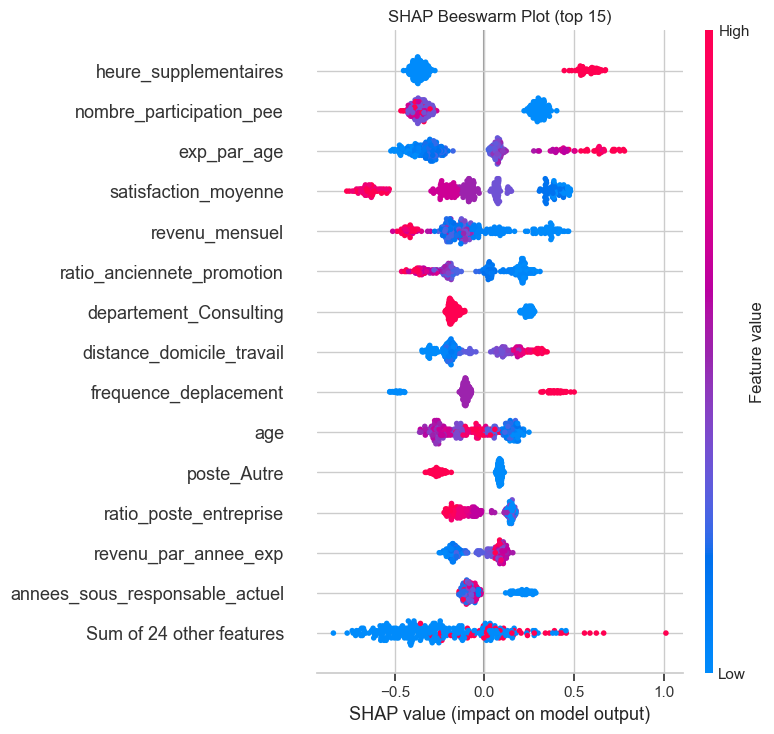

In [15]:
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title("SHAP Beeswarm Plot (top 15)")
plt.tight_layout()
plt.show()

### SHAP Scatter Plot

Le scatter plot montre en détail comment une feature influence la prédiction.  
L'argument `color` colore les points par une autre variable, ce qui permet de repérer des interactions entre features.

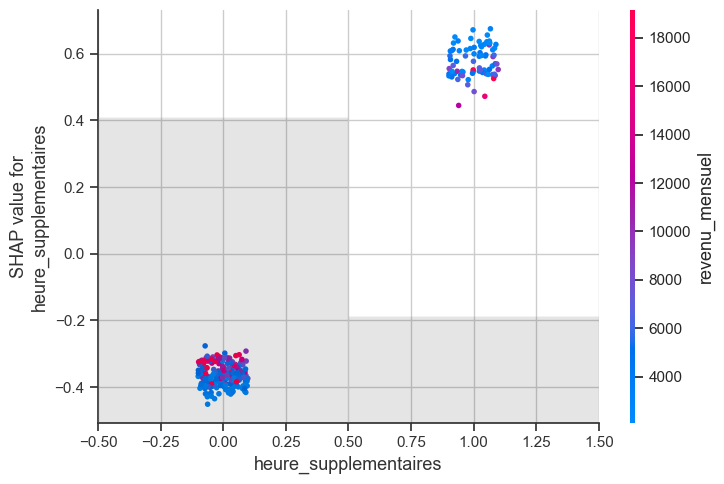

In [16]:
shap.plots.scatter(shap_values[:, "heure_supplementaires"], color=shap_values[:, "revenu_mensuel"], show=False)
plt.tight_layout()
plt.show()

### Synthèse de l'importance globale

On compare les top features selon les trois méthodes pour identifier les points de convergence et de divergence.

In [18]:
top_native = native_importance.head(10)["feature"].tolist()
top_perm = perm_importance.head(10)["feature"].tolist()

shap_mean_abs = pd.DataFrame({
    "feature": X.columns,
    "mean_abs_shap": np.abs(shap_values.values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)
top_shap = shap_mean_abs.head(10)["feature"].tolist()

comparison_fi = pd.DataFrame({
    "rang": range(1, 11),
    "native_xgboost": top_native,
    "permutation": top_perm,
    "shap": top_shap
})

display(comparison_fi)

,rang,native_xgboost,permutation,shap
0,1,hs_et_bas_salaire,heure_supplementaires,heure_supplementaires
1,2,annees_dans_l_entreprise,nombre_participation_pee,nombre_participation_pee
2,3,ratio_anciennete_promotion,ratio_anciennete_promotion,exp_par_age
3,4,domaine_etude_Marketing,poste_Autre,satisfaction_moyenne
4,5,annee_experience_totale,satisfaction_moyenne,revenu_mensuel
5,6,poste_Autre,exp_par_age,ratio_anciennete_promotion
6,7,nombre_participation_pee,revenu_mensuel,departement_Consulting
7,8,heure_supplementaires,distance_domicile_travail,distance_domicile_travail
8,9,satisfaction_moyenne,frequence_deplacement,frequence_deplacement
9,10,exp_par_age,hs_et_bas_salaire,age


In [19]:
common = set(top_native) & set(top_perm) & set(top_shap)
print(f"Features présentes dans les 3 top 10 : {common}")

Features présentes dans les 3 top 10 : {'exp_par_age', 'ratio_anciennete_promotion', 'satisfaction_moyenne', 'heure_supplementaires', 'nombre_participation_pee'}


---

## Feature importance locale

L'importance locale permet de comprendre pourquoi le modèle a pris une décision pour un employé en particulier.  
Le waterfall plot montre la contribution de chaque feature à la prédiction individuelle.

### Employé prédit comme "parti" (vrai positif)

On choisit un employé que le modèle a correctement identifié comme étant parti.

In [20]:
y_test_pred = (test_proba_tuned >= threshold).astype(int)
vp_mask = (y_test == 1) & (y_test_pred == 1)
vp_indices = np.where(vp_mask)[0]

print(f"Nombre de vrais positifs : {len(vp_indices)}")

idx_vp = vp_indices[0]
print(f"Employé sélectionné (index dans X_test) : {idx_vp}")
print(f"Prédiction : {y_test_pred[idx_vp]}, Réalité : {y_test.iloc[idx_vp]}")

Nombre de vrais positifs : 32
Employé sélectionné (index dans X_test) : 4
Prédiction : 1, Réalité : 1


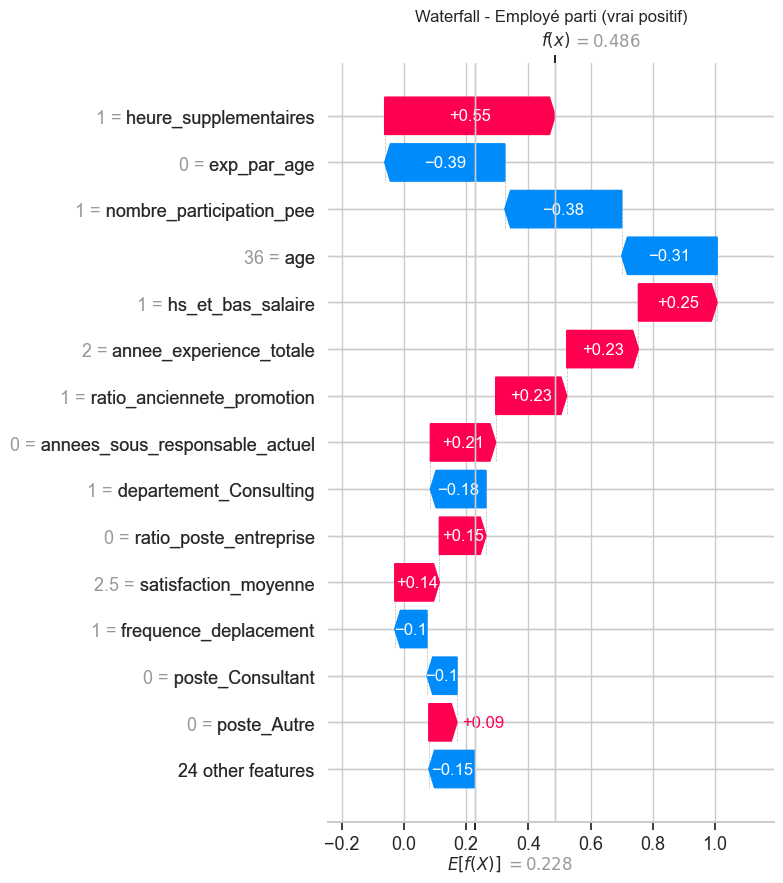

In [21]:
shap.plots.waterfall(shap_values[idx_vp], max_display=15, show=False)
plt.title("Waterfall - Employé parti (vrai positif)")
plt.tight_layout()
plt.show()

### Employé prédit comme "resté" (vrai négatif)

On choisit un employé que le modèle a correctement identifié comme étant resté.

In [22]:
vn_mask = (y_test == 0) & (y_test_pred == 0)
vn_indices = np.where(vn_mask)[0]

print(f"Nombre de vrais négatifs : {len(vn_indices)}")

idx_vn = vn_indices[0]
print(f"Employé sélectionné (index dans X_test) : {idx_vn}")
print(f"Prédiction : {y_test_pred[idx_vn]}, Réalité : {y_test.iloc[idx_vn]}")

Nombre de vrais négatifs : 209
Employé sélectionné (index dans X_test) : 1
Prédiction : 0, Réalité : 0


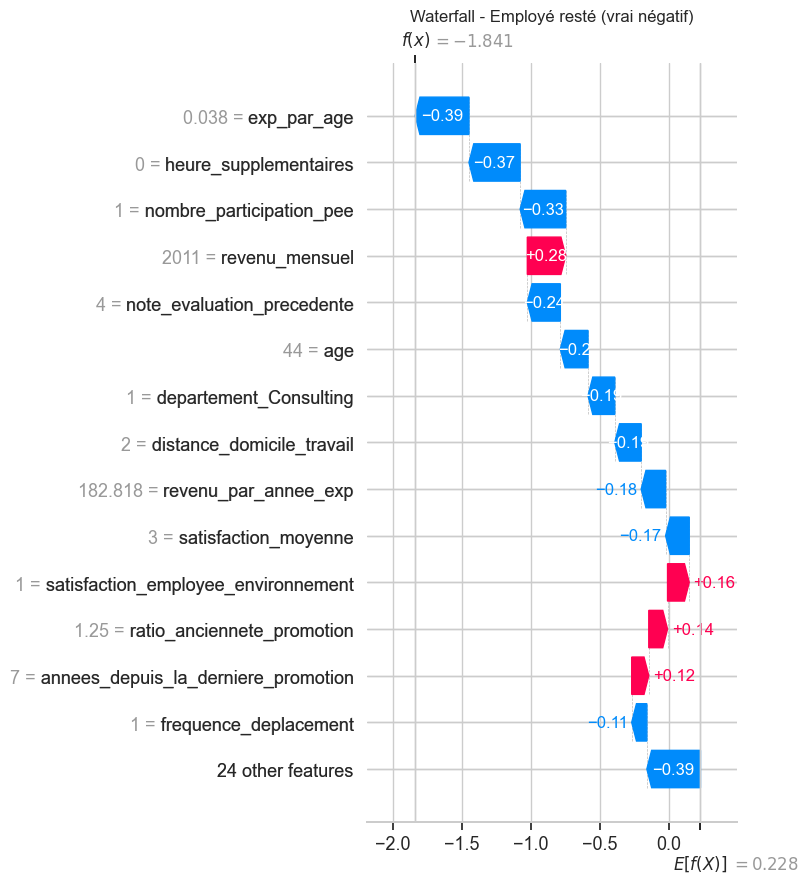

In [23]:
shap.plots.waterfall(shap_values[idx_vn], max_display=15, show=False)
plt.title("Waterfall - Employé resté (vrai négatif)")
plt.tight_layout()
plt.show()

---

## Interprétation et recommandations

### Synthèse des causes d'attrition identifiées

Les trois méthodes d'importance globale convergent vers les mêmes facteurs principaux de départ :

- **Les heures supplémentaires** ressortent systématiquement comme le facteur le plus discriminant. Les employés qui en font ont un risque de départ beaucoup plus élevé.
- **La satisfaction** (moyenne des 4 dimensions) joue un rôle important : les employés peu satisfaits sont plus susceptibles de partir.
- **La combinaison heures supplémentaires + bas salaire** (`hs_et_bas_salaire`) confirme que la charge de travail est d'autant plus mal vécue lorsque la rémunération est perçue comme insuffisante.
- **L'ancienneté et la promotion** : les employés n'ayant pas été promus depuis longtemps, ou restés longtemps dans le même poste, présentent un risque plus élevé.
- **La participation au PEE** (plan d'épargne entreprise) semble avoir un effet protecteur, ce qui pourrait refléter un engagement plus fort envers l'entreprise.

Ces constats sont cohérents avec les observations de l'analyse exploratoire du notebook 01.

### Recommandations pour les RH de TechNova

Sur la base de ces résultats, plusieurs leviers d'action peuvent être envisagés :

1. **Surveiller la charge de travail** : mettre en place un suivi des heures supplémentaires et agir lorsqu'elles deviennent régulières, en particulier pour les employés à revenus modestes.

2. **Revaloriser les salaires des profils à risque** : les employés cumulant heures supplémentaires et rémunération sous la médiane constituent un groupe à risque identifié. Une politique d'ajustement salarial ciblée pourrait réduire l'attrition.

3. **Dynamiser les parcours professionnels** : les employés bloqués dans le même poste depuis longtemps, sans promotion récente, sont plus susceptibles de partir. Des entretiens de carrière réguliers et des opportunités de mobilité interne pourraient limiter ce phénomène.

4. **Renforcer les enquêtes de satisfaction** : les scores de satisfaction étant des indicateurs précoces de risque de départ, il serait utile de les suivre de manière rapprochée et d'agir rapidement en cas de baisse.

5. **Promouvoir le PEE et les dispositifs d'engagement** : la participation au plan d'épargne entreprise semble associée à un taux de départ plus faible. Encourager l'adhésion à ces dispositifs pourrait contribuer à renforcer l'attachement à l'entreprise.

### Limites

- Le modèle identifie des corrélations, pas des causalités. Par exemple, les heures supplémentaires sont associées au départ, mais c'est peut-être un autre facteur (stress, management) qui cause à la fois les heures supplémentaires et le départ.
- La taille du dataset (1470 observations) limite la capacité du modèle à capturer des patterns fins.
- Certaines dimensions (qualité du management, perspectives d'évolution ressenties, offres concurrentes) ne sont pas dans les données et pourraient expliquer une part importante de l'attrition.